In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df  = pd.read_csv("/content/sample_data/loan_approval_dataset.csv")
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1   no_of_dependents           4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [9]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4264,False
4265,False
4266,False
4267,False


In [10]:
from sklearn.preprocessing import LabelEncoder   # covert into numeric data

In [11]:
lc = LabelEncoder()

In [12]:
for i in df.columns:
  if df[i].dtype == 'object':
    df[i] = lc.fit_transform(df[i])

In [13]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,0,1,1000000,2300000,12,317,2800000,500000,3300000,800000,1
4265,4266,0,1,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,0
4266,4267,2,1,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,1
4267,4268,1,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1   no_of_dependents           4269 non-null   int64
 2    education                 4269 non-null   int64
 3    self_employed             4269 non-null   int64
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   int64
dtypes: int64(13)
memory usage: 433.7 KB


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
X = df.drop(' loan_status', axis=1)
y = df[' loan_status']

In [23]:
X

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,0,1,1000000,2300000,12,317,2800000,500000,3300000,800000
4265,4266,0,1,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000
4266,4267,2,1,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000
4267,4268,1,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000


In [24]:
y

,loan_status
0,0
1,1
2,1
3,1
4,1
...,...
4264,1
4265,0
4266,1
4267,0


In [25]:
# Training and testing data testing data 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [26]:
st = StandardScaler()

In [27]:
# Scaled the data into 0 - 1
X_train_scaled = st.fit_transform(X_train)
X_test_scaled = st.fit_transform(X_test)

In [29]:
from sklearn.svm import SVC    # SVC Model

In [34]:
sv = SVC(kernel='rbf', degree=3, gamma='auto', random_state=42 , verbose=True)

In [35]:
modelsvc = sv.fit(X_train_scaled , y_train)
modelsvc

[LibSVM]

SVC(gamma='auto', random_state=42, verbose=True)

In [41]:
y_predsvc = modelsvc.predict(X_test_scaled)

In [42]:
from sklearn.metrics import *

In [45]:
print(classification_report(y_predsvc , y_test))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       531
           1       0.92      0.90      0.91       323

    accuracy                           0.93       854
   macro avg       0.93      0.93      0.93       854
weighted avg       0.93      0.93      0.93       854



In [46]:
from sklearn.ensemble import GradientBoostingClassifier   # GradientBoostingClassifier  model

In [49]:
gbc = GradientBoostingClassifier(loss='log_loss', learning_rate=0.1, n_estimators=100, subsample=1.0,max_depth=10 , criterion='friedman_mse',random_state=42,verbose=True)

In [50]:
modelgbc = gbc.fit(X_train_scaled , y_train)
modelgbc

      Iter       Train Loss   Remaining Time 
         1           1.1406            6.05s
         2           0.9905            5.20s
         3           0.8674            4.87s
         4           0.7637            4.85s
         5           0.6756            4.55s
         6           0.5995            4.48s
         7           0.5339            4.39s
         8           0.4762            4.26s
         9           0.4259            4.04s
        10           0.3820            3.82s
        20           0.1364            3.05s
        30           0.0511            2.53s
        40           0.0199            2.29s
        50           0.0083            1.76s
        60           0.0036            1.34s
        70           0.0017            0.95s
        80           0.0009            0.61s
        90           0.0004            0.32s
       100           0.0002            0.00s


GradientBoostingClassifier(max_depth=10, random_state=42, verbose=True)

In [51]:
y_pred_gbc = modelgbc.predict(X_test_scaled)

In [52]:
print(classification_report(y_pred_gbc , y_test))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.96      0.96      0.96       318

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [53]:
from sklearn.ensemble import AdaBoostClassifier   # AdaBoostClassifier model

In [54]:
abd = AdaBoostClassifier(n_estimators=100, learning_rate=1.0 , random_state=42 )


In [56]:
modelabd = abd.fit(X_train_scaled , y_train)
modelabd

AdaBoostClassifier(n_estimators=100, random_state=42)

In [57]:
y_pred_abd = modelabd.predict(X_test_scaled)

In [58]:
print(classification_report(y_pred_abd , y_test))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       540
           1       0.94      0.95      0.95       314

    accuracy                           0.96       854
   macro avg       0.96      0.96      0.96       854
weighted avg       0.96      0.96      0.96       854



In [59]:
import xgboost as xg # XG boost model

In [60]:
params = {
    'objective':'binary:logistic',
    'max_depth':5,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10
}

In [63]:
modelxg = xg.XGBClassifier(**params)

In [64]:
modelxg.fit(X_train_scaled , y_train)
modelxg

XGBClassifier(alpha=10, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, ...)

In [65]:
y_pred_xg = modelxg.predict(X_test_scaled)

In [66]:
print(classification_report(y_pred_xg , y_test))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       555
           1       0.93      0.99      0.96       299

    accuracy                           0.97       854
   macro avg       0.96      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



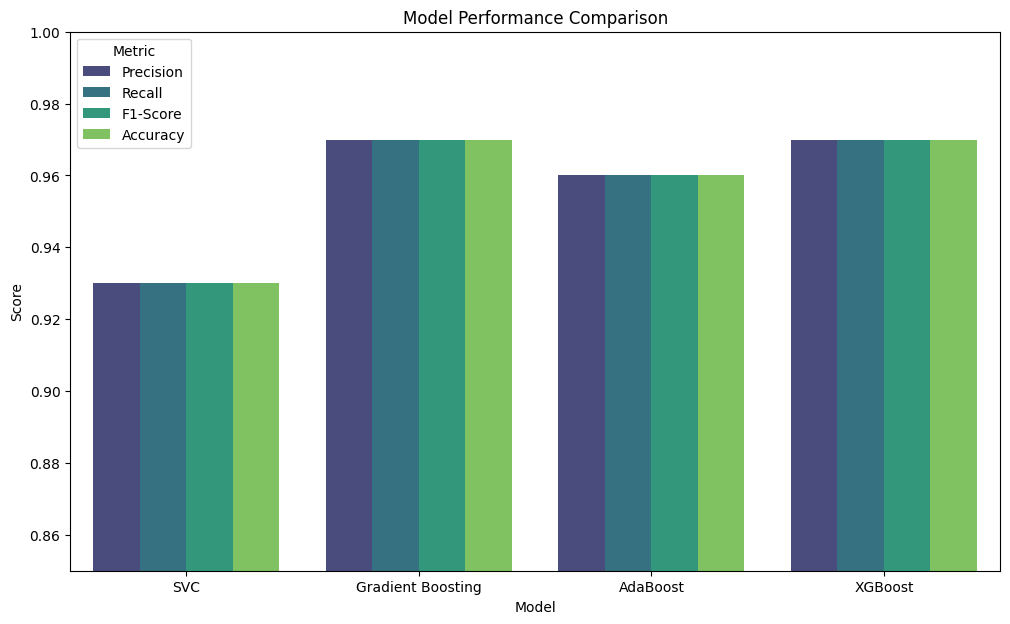

In [67]:
svc_metrics = {
    'precision': 0.93,
    'recall': 0.93,
    'f1-score': 0.93,
    'accuracy': 0.93
}
gbc_metrics = {
    'precision': 0.97,
    'recall': 0.97,
    'f1-score': 0.97,
    'accuracy': 0.97
}
abd_metrics = {
    'precision': 0.96,
    'recall': 0.96,
    'f1-score': 0.96,
    'accuracy': 0.96
}
xg_metrics = {
    'precision': 0.97,
    'recall': 0.97,
    'f1-score': 0.97,
    'accuracy': 0.97
}

metrics_df = pd.DataFrame({
    'Model': ['SVC', 'Gradient Boosting', 'AdaBoost', 'XGBoost'],
    'Precision': [svc_metrics['precision'], gbc_metrics['precision'], abd_metrics['precision'], xg_metrics['precision']],
    'Recall': [svc_metrics['recall'], gbc_metrics['recall'], abd_metrics['recall'], xg_metrics['recall']],
    'F1-Score': [svc_metrics['f1-score'], gbc_metrics['f1-score'], abd_metrics['f1-score'], xg_metrics['f1-score']],
    'Accuracy': [svc_metrics['accuracy'], gbc_metrics['accuracy'], abd_metrics['accuracy'], xg_metrics['accuracy']]
})

metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_df_melted, palette='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.85, 1.0)
plt.show()